In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 7.6 MB/s eta 0:00:00


# Model Training: Regime Detection (HMM + LSTM)
**Objective:** Financial markets transition through distinct, latent states. Pure price-prediction models fail because they attempt to fit a single set of weights to varying statistical environments.
Here, we will:
1. **Offline Phase:** Use a Gaussian Hidden Markov Model (HMM) to mathematically discover the "Ground Truth" regimes from our training data.
2. **Online Phase:** Train an LSTM with a 48-bar lookback window to classify real-time market data into these HMM-derived states.

In [4]:
import os
import sys
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append(os.path.abspath('/content/drive/MyDrive/TimeSeries_AI/src'))
from models.regime_hmm_lstm import RegimeHMM, RegimeLSTM

# Plotting config
plt.style.use('dark_background')
sns.set_palette("bright")

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cuda


## 1. Unsupervised Ground Truth: The Hidden Markov Model
We fit the HMM on our historical training data. We explicitly set the number of components to $N=3$ to represent Downtrend, Uptrend, and Mean-Reverting/Chop states.

*Note: The HMM is heavily influenced by returns and volatility. We will use `log_return` and `rv_1h` (1-hour realized volatility) as its primary clustering features.*

In [5]:
# Load preprocessed datasets
train_df = pd.read_csv('/content/drive/MyDrive/TimeSeries_AI/data/processed/train_engineered.csv', index_col=0, parse_dates=True)
val_df = pd.read_csv('/content/drive/MyDrive/TimeSeries_AI/data/processed/val_engineered.csv', index_col=0, parse_dates=True)

# Select features for the HMM clustering (Keep it simple: Direction + Magnitude)
hmm_features = ['log_return', 'rv_1h']

X_hmm_train = train_df[hmm_features].values
X_hmm_val = val_df[hmm_features].values

# Initialize and fit HMM
hmm_model = RegimeHMM(n_components=3, random_state=42)
hmm_model.fit(X_hmm_train)

# Generate the "Ground Truth" integer labels [0, 1, 2]
train_labels = hmm_model.predict(X_hmm_train)
val_labels = hmm_model.predict(X_hmm_val)

# Add labels back to dataframes
train_df['regime_label'] = train_labels
val_df['regime_label'] = val_labels

print(f"Train Labels Distribution: {np.bincount(train_labels)}")
print(f"Val Labels Distribution:   {np.bincount(val_labels)}")

# Save the offline HMM model
os.makedirs('./content/drive/MyDrive/TimeSeries_AI/weights', exist_ok=True)
hmm_model.save('/content/drive/MyDrive/TimeSeries_AI/weights/regime_hmm_best.pkl')

Train Labels Distribution: [66270 77672 29146]
Val Labels Distribution:   [12656 16471  5722]


## 2. Visualizing the Discovered Regimes
Before we train the LSTM, we must verify that the HMM clustered the data logically. We expect to see periods of high volatility grouped differently than tight, ranging periods.

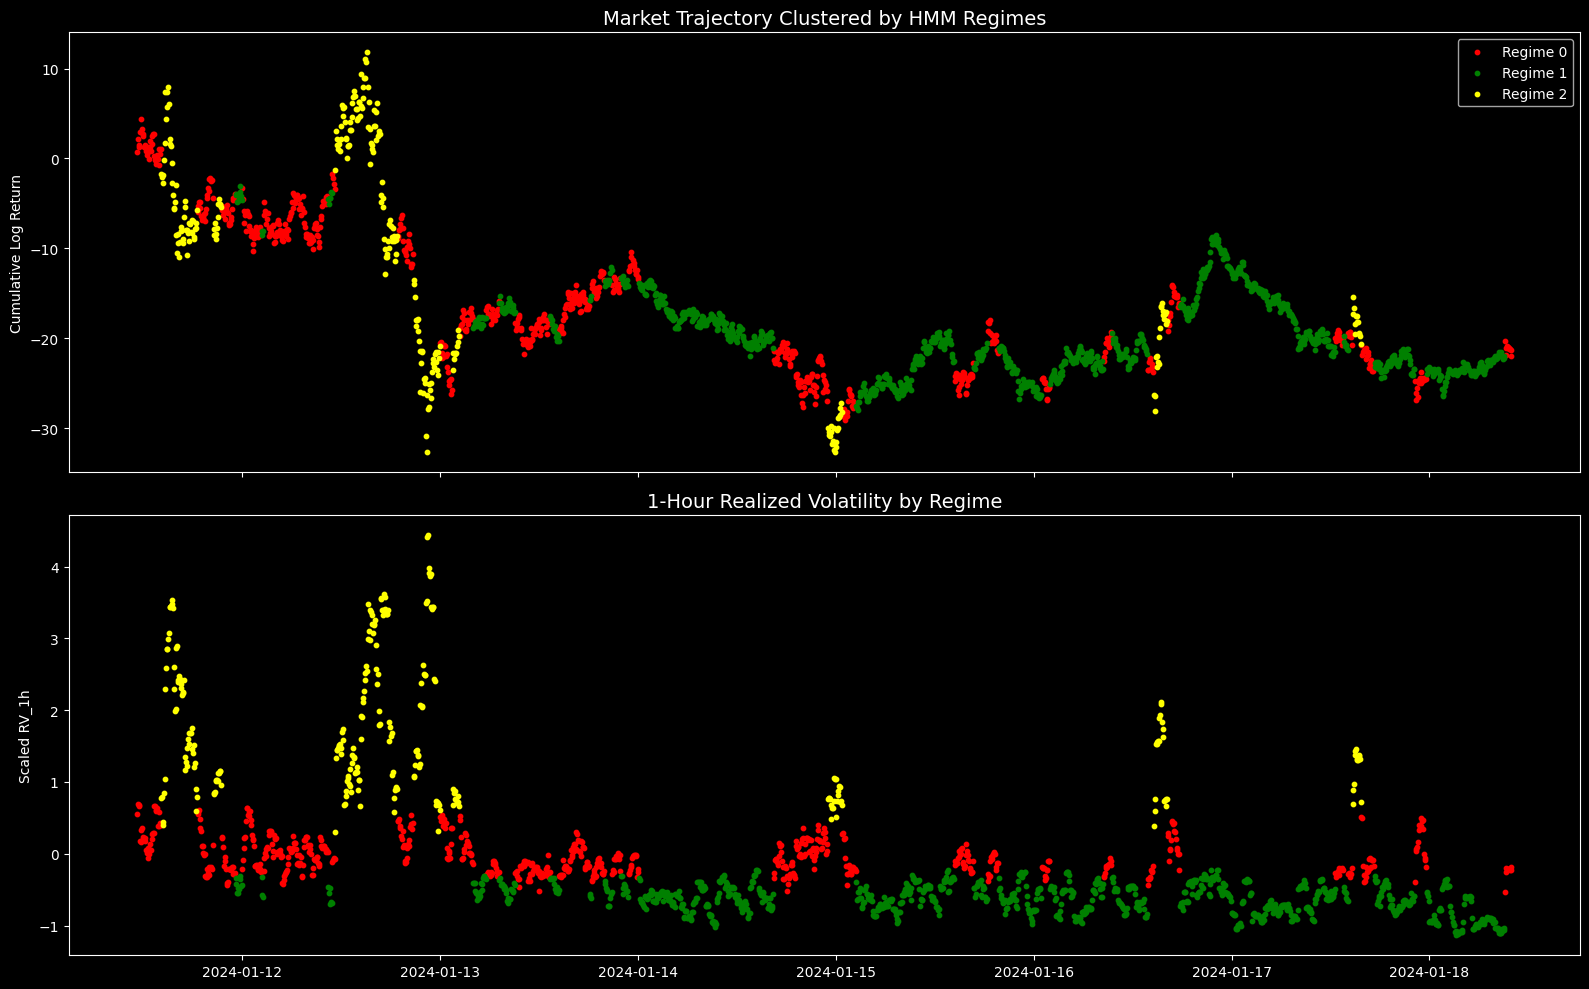

In [6]:
# Plot a 2-week slice to see the regime transitions clearly
plot_df = train_df.iloc[1000:3000]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Plot 1: Cumulative Returns colored by Regime
colors = ['red', 'green', 'yellow']
regime_names = ['State 0', 'State 1', 'State 2'] # You will need to inspect the plot to assign semantic meaning

cumulative_returns = np.cumsum(plot_df['log_return'])

for i in range(3):
    mask = plot_df['regime_label'] == i
    ax1.scatter(plot_df.index[mask], cumulative_returns[mask], color=colors[i], label=f'Regime {i}', s=10)

ax1.set_title('Market Trajectory Clustered by HMM Regimes', fontsize=14)
ax1.set_ylabel('Cumulative Log Return')
ax1.legend()

# Plot 2: Volatility profile of the regimes
for i in range(3):
    mask = plot_df['regime_label'] == i
    ax2.scatter(plot_df.index[mask], plot_df['rv_1h'][mask], color=colors[i], s=10)

ax2.set_title('1-Hour Realized Volatility by Regime', fontsize=14)
ax2.set_ylabel('Scaled RV_1h')

plt.tight_layout()
plt.show()

## 3. Data Preparation: LSTM Sequence Generation
The C++ Hub streams raw ticks asynchronously, but our model processes data via a `collections.deque(maxlen=48)`. We now slice our full feature matrix into rolling 48-bar windows. The target $Y$ is the HMM regime of the *current* bar at the end of the window.

In [7]:
def create_regime_sequences(df, feature_cols, target_col, seq_length=48):
    X, y = [], []
    data_feat = df[feature_cols].values
    data_target = df[target_col].values

    for i in range(len(data_feat) - seq_length):
        X.append(data_feat[i:i+seq_length])
        y.append(data_target[i+seq_length-1]) # Target is the regime of the last bar in the sequence

    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.long)

# We use all available engineered features for the LSTM to maximize its context
LSTM_FEATURES = [
    'log_return', 'log_volume_usdt', 'rv_1h', 'rv_1d', 'rv_1w',
    'garman_klass_vol', 'rsi_14', 'ema_ratio', 'avg_trade_size',
    'volume_z_score', 'amihud_illiquidity', 'vol_imbalance', 'vol_to_vol_ratio',
    'sin_day', 'cos_day', 'sin_week', 'cos_week'
]

X_train_seq, y_train_seq = create_regime_sequences(train_df, LSTM_FEATURES, 'regime_label', seq_length=48)
X_val_seq, y_val_seq = create_regime_sequences(val_df, LSTM_FEATURES, 'regime_label', seq_length=48)

train_loader = DataLoader(TensorDataset(X_train_seq, y_train_seq), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_seq, y_val_seq), batch_size=128, shuffle=False)

print(f"Train Tensor Shape: {X_train_seq.shape}")
print(f"Val Tensor Shape:   {X_val_seq.shape}")

Train Tensor Shape: torch.Size([173040, 48, 17])
Val Tensor Shape:   torch.Size([34801, 48, 17])


## 4. Supervised Inference: Training the LSTM
We utilize a tight hidden bottleneck of 32 neurons to force the network to learn only the most robust macro features, applying 0.3 dropout for heavy regularization.

*Implementation Note:* Our `RegimeLSTM` outputs normalized probabilities via a `Softmax` layer. PyTorch's `nn.CrossEntropyLoss` expects raw, unnormalized logits. Therefore, we will take the logarithm of our probabilities and use `nn.NLLLoss` (Negative Log Likelihood Loss) to compute the gradients correctly.

In [8]:
# Initialize LSTM
lstm_model = RegimeLSTM(
    input_size=len(LSTM_FEATURES),
    hidden_size=32,
    num_layers=2,
    dropout=0.3,
    num_classes=3
).to(device)

# Using NLLLoss because our model outputs Softmax probabilities
criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-5)

epochs = 15
best_val_loss = float('inf')

print("Starting LSTM Training...")
for epoch in range(epochs):
    # --- TRAIN ---
    lstm_model.train()
    train_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        # Model outputs probabilities, we need log probabilities for NLLLoss
        probs = lstm_model(X_batch)
        log_probs = torch.log(probs + 1e-8)

        loss = criterion(log_probs, y_batch)
        loss.backward()

        # Gradient clipping to prevent exploding gradients in LSTMs
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(probs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    train_acc = 100 * correct / total

    # --- VALIDATION ---
    lstm_model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            probs = lstm_model(X_batch)
            log_probs = torch.log(probs + 1e-8)

            loss = criterion(log_probs, y_batch)
            val_loss += loss.item()

            _, predicted = torch.max(probs.data, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()

    val_acc = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} - Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} - Acc: {val_acc:.2f}%")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(lstm_model.state_dict(), '/content/drive/MyDrive/TimeSeries_AI/weights/regime_lstm_best.pth')

print("\nTraining Complete. Best weights saved to ../weights/regime_lstm_best.pth")

Starting LSTM Training...
Epoch 01/15 | Train Loss: 0.2273 - Acc: 90.30% | Val Loss: 0.1123 - Acc: 95.16%
Epoch 02/15 | Train Loss: 0.1217 - Acc: 94.85% | Val Loss: 0.1027 - Acc: 95.56%
Epoch 03/15 | Train Loss: 0.1124 - Acc: 95.17% | Val Loss: 0.0952 - Acc: 96.05%
Epoch 04/15 | Train Loss: 0.1077 - Acc: 95.36% | Val Loss: 0.0951 - Acc: 95.78%
Epoch 05/15 | Train Loss: 0.1047 - Acc: 95.48% | Val Loss: 0.0916 - Acc: 96.04%
Epoch 06/15 | Train Loss: 0.1016 - Acc: 95.59% | Val Loss: 0.0924 - Acc: 95.93%
Epoch 07/15 | Train Loss: 0.0998 - Acc: 95.70% | Val Loss: 0.0959 - Acc: 95.90%
Epoch 08/15 | Train Loss: 0.0977 - Acc: 95.78% | Val Loss: 0.0939 - Acc: 95.93%
Epoch 09/15 | Train Loss: 0.0959 - Acc: 95.88% | Val Loss: 0.0939 - Acc: 95.81%
Epoch 10/15 | Train Loss: 0.0939 - Acc: 95.95% | Val Loss: 0.0912 - Acc: 95.93%
Epoch 11/15 | Train Loss: 0.0912 - Acc: 96.07% | Val Loss: 0.0936 - Acc: 95.81%
Epoch 12/15 | Train Loss: 0.0906 - Acc: 96.09% | Val Loss: 0.0955 - Acc: 95.74%
Epoch 13/15 | 